# Overlap of DEGs
For both phase 1 oysters and phase 2 oysters, I ran DESeq but isolated the effects of phase 1 (and 2) temperature and DO treatments (so identified DEGs for phase 2 warm vs. ambient, ignoring the effects of phase 1 and phase 2 DO treamtents). I'm now curious if there is overlap between the DEGs I've identified in phase 1 and phase 2.

## 0. load libraries

In [18]:
library(tidyverse)
library(UpSetR)
library(ggvenn)

Loading required package: grid



## 1. load CSVs

#### phase 1 oysters

In [3]:
p1_DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/hypoxic_v_normoxic.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p1_DO) # 65 DEGs

[1] 65  8

In [4]:
p1_temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/warm_v_ambient.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p1_temp) # 100 DEGs

[1] 100   8

#### phase 2 oysters

In [5]:
p2_p1.DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/isolated_treatments/p1_DO.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p1.DO) # 55 DEGs

[1]  55 102

In [6]:
p2_p1.temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/isolated_treatments/p1_temp.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p1.temp) # 27 DEGs

[1]  27 102

In [7]:
p2_p2.DO <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/isolated_treatments/p2_DO.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p2.DO) # 67 DEGs

[1]  67 102

In [8]:
p2_p2.temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/isolated_treatments/p2_temp.csv') %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1)
dim(p2_p2.temp) # 167 DEGs

[1] 167 102

## 2. UpSet Plots

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


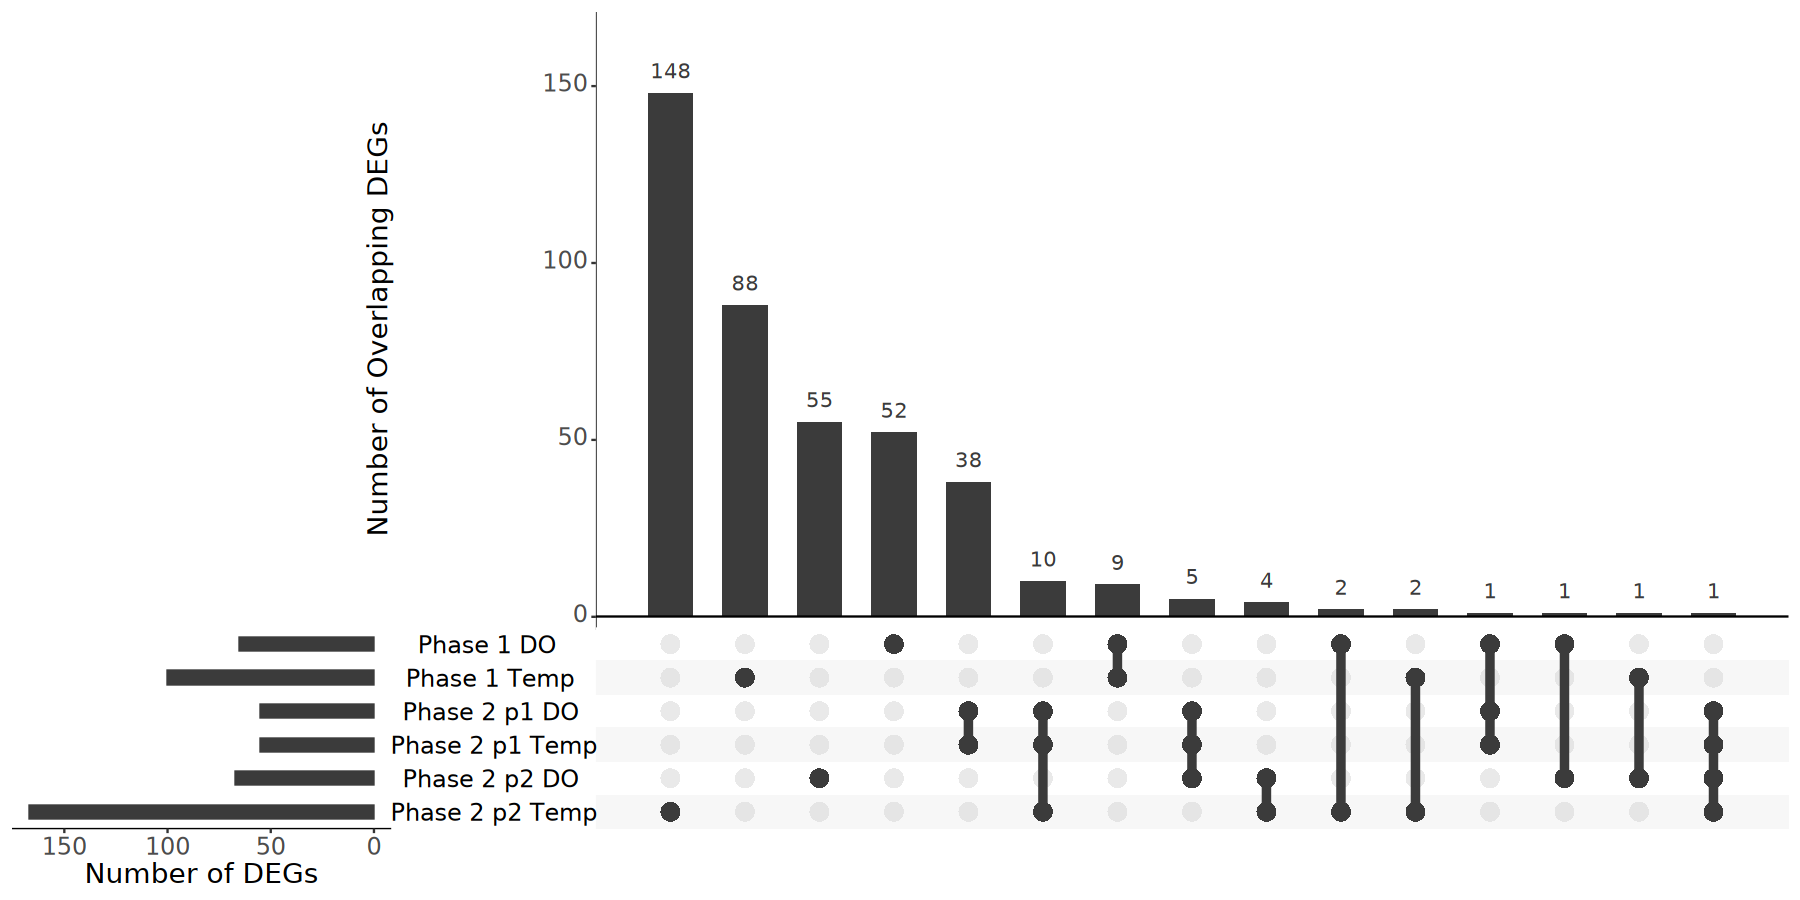

In [9]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

# make list for input into upset
DEGs = list('Phase 1 DO' = p1_DO$X,
            'Phase 1 Temp' = p1_temp$X,
            'Phase 2 p1 DO' = p2_p1.DO$Gene,
            'Phase 2 p1 Temp' = p2_p1.DO$Gene,
            'Phase 2 p2 DO' = p2_p2.DO$Gene,
            'Phase 2 p2 Temp' = p2_p2.temp$Gene)

# plot
upset(
  fromList(DEGs),
    sets = rev(names(DEGs)),   # enforce order
  keep.order = TRUE,
  order.by = "freq",
  nsets = 6,
  point.size = 5,
  line.size = 2,
  mainbar.y.label = "Number of Overlapping DEGs",
  sets.x.label = "Number of DEGs",
  text.scale = c(2, 2, 2, 2, 2, 2)
)

- 38 DEGs are shared in phase 2 oysters phase 1 treatments (so general response to early stressors? "memory" genes?)
- there are not many DEGs that are shared between phase 1 and phase 2 oysters
    - 2 shared between phase 2 p2 temp and phase 1 DO (??)
    - 2 shared between phase 2 p2 temp and phase 1 temp (interesting! maintained expr/memory of past environment? would be interesting to see if they're similarly expressed)
    - there are other DEGs that are shared between phase 1 and 2 oysters but there's only 1 for each grouping (right of the plot)
- 1 DEG that is shared in all of the Phase 2 oysters 

## 3. venn diagram of isolated treatments
using [ggvenn](https://github.com/yanlinlin82/ggvenn)

#### temperature

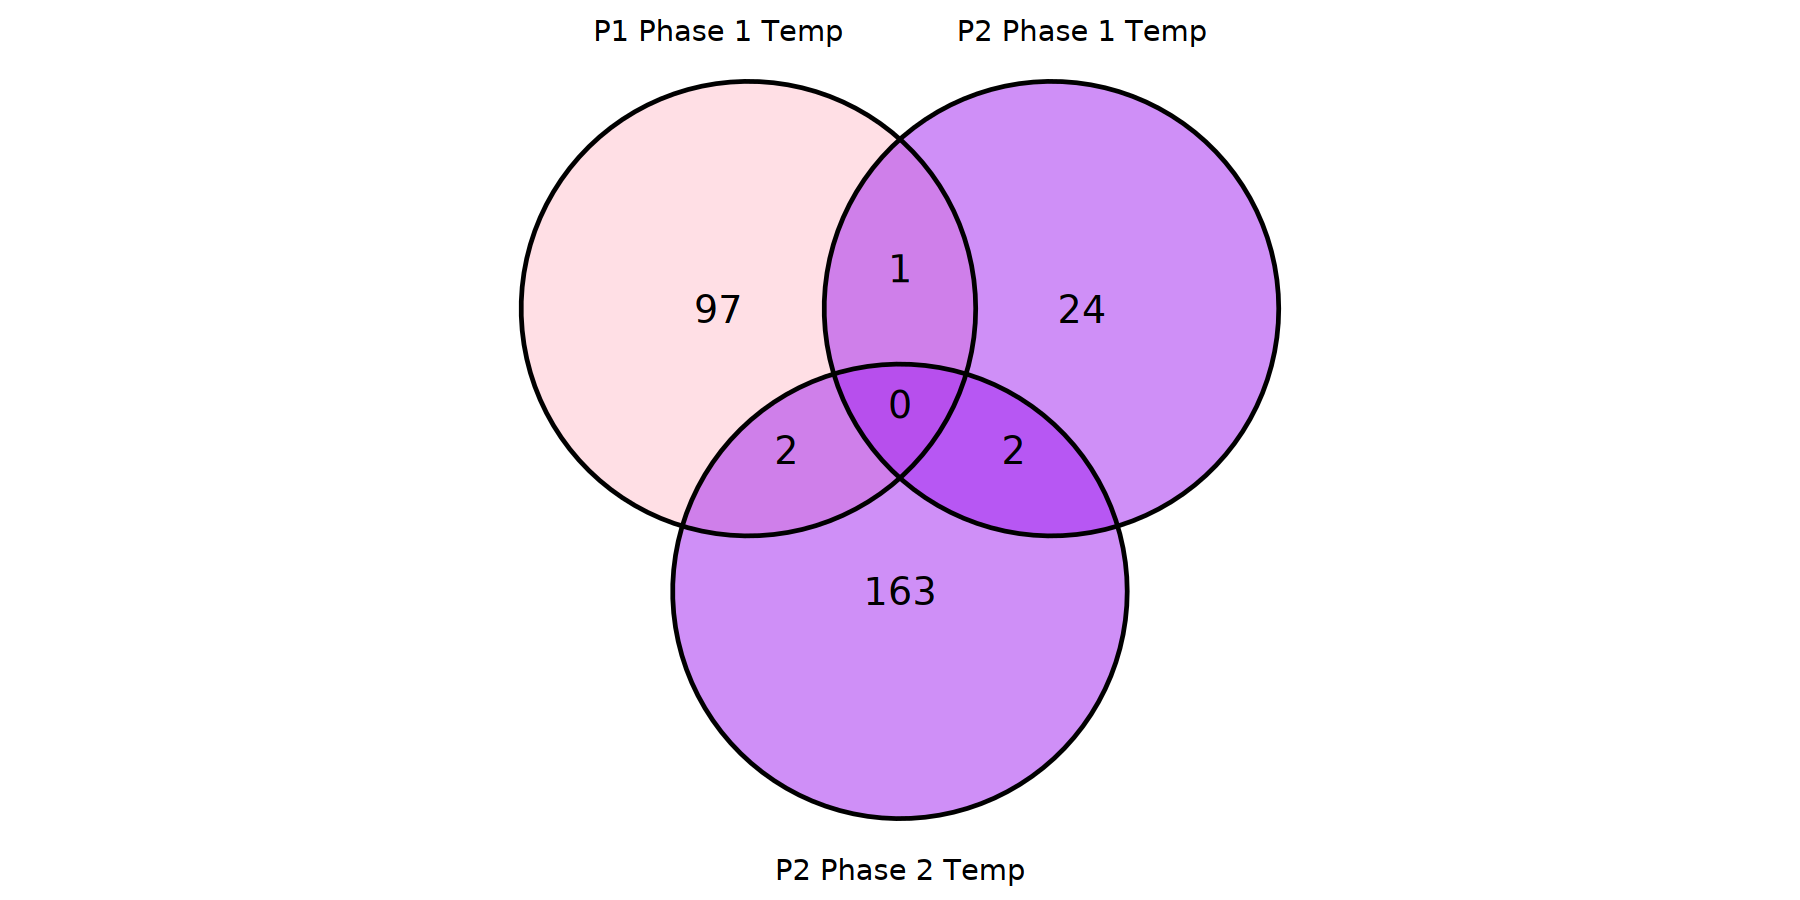

In [45]:
temp = list('P1 Phase 1 Temp' = p1_temp$X,
            'P2 Phase 1 Temp' = p2_p1.temp$Gene,
            'P2 Phase 2 Temp' = p2_p2.temp$Gene)

ggvenn(temp,
      text_size = 8,
       fill_color = c('pink', 'purple', 'purple'),
      show_percentage = FALSE)

purple = phase 2 oysters, pink = phase 1 oysters

**observations**:
- 5 DEGs shared total
- no shared DEGs between all 3 temp groups (so no constitutive expression?)
- 3 shared between phase 1 oysters and phase 2 oysters - 2 with phase 2 oysters late and 1 with phase 2 oysters early
- 2 shared DEGs shared between phase 2 oysters

#### dissolved oxygen

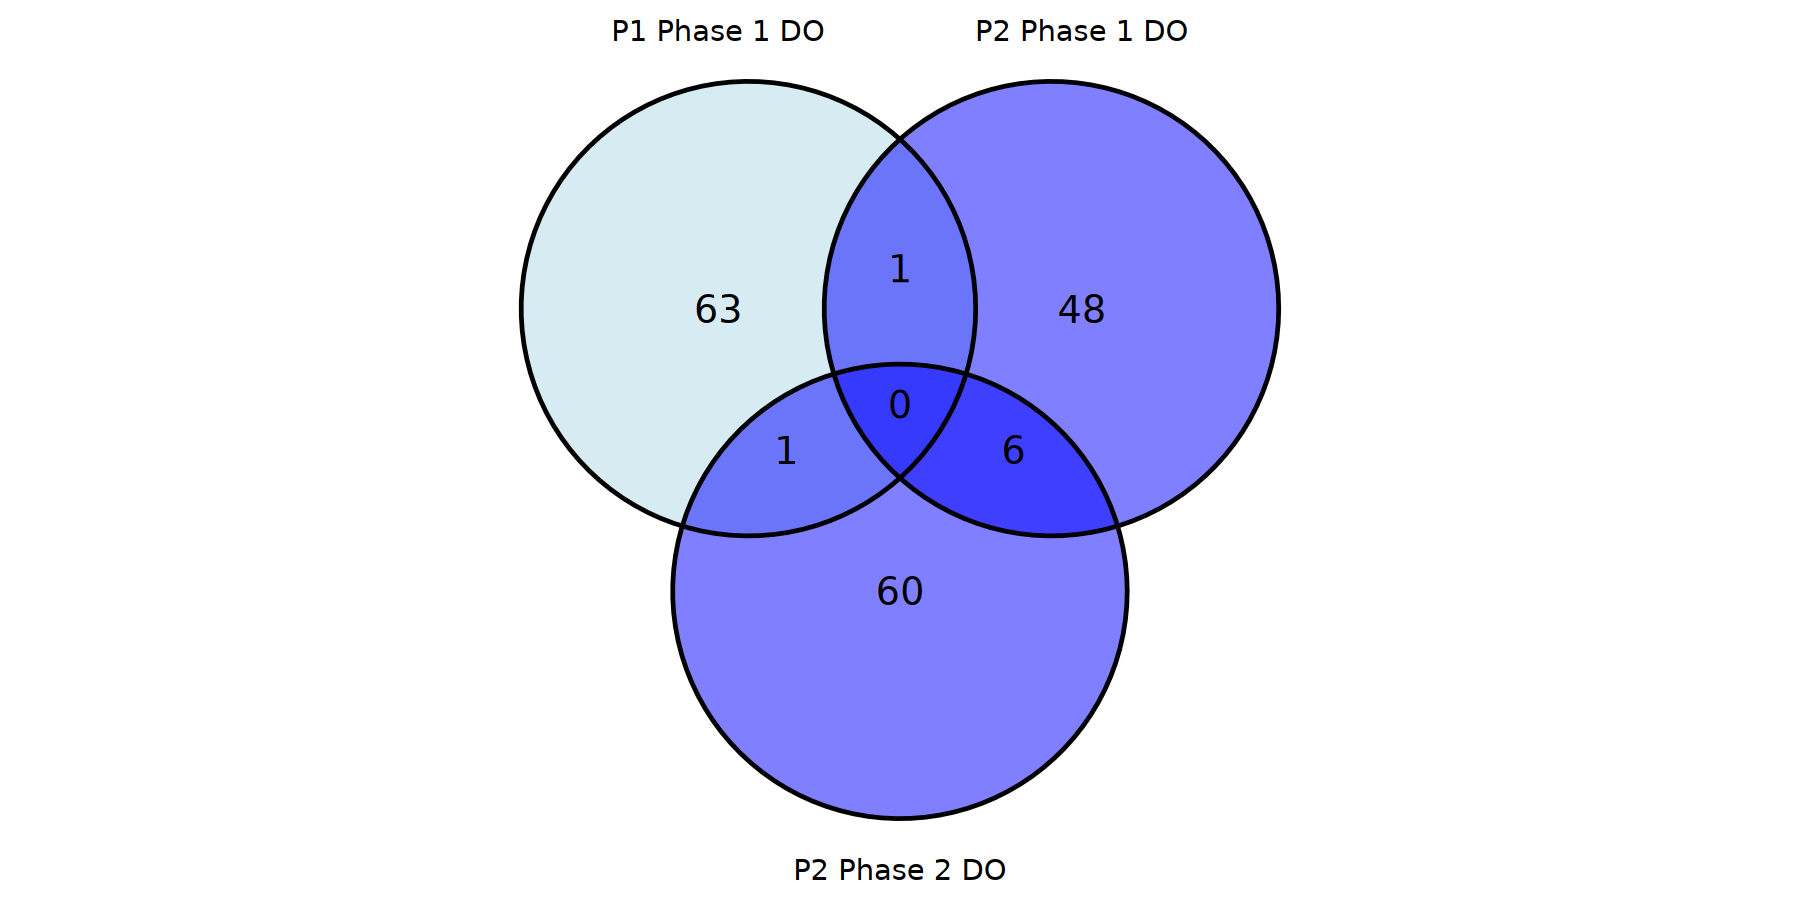

In [44]:
do = list('P1 Phase 1 DO' = p1_DO$X,
            'P2 Phase 1 DO' = p2_p1.DO$Gene,
            'P2 Phase 2 DO' = p2_p2.DO$Gene)

ggvenn(do,
      text_size = 8,
       fill_color = c('lightblue', 'blue', 'blue'),
      show_percentage = FALSE)

light blue = phase 1 oysters, dark blue = phase 2 oysters

**observations**:
- 8 DEGs shared total
- no shared DEGs between all 3 DO groups (so no constitutive expression?)
- 2 shared between phase 1 and phase 2 oysters - 1 with phase 2 oysters late and 1 with phase 2 oysters early
- 6 shared between phase 2 oysters

### overall:
As a reminder, these DEGs were identified by isolating the treatments/ignoring the effects of other things - so for phase 2 oysters, DEGs are for phase 1 warm vs. ambient (ignoring the phase 1 temperature and phase 2 treatments (so CC, CW, CH, CB, HC, HH, HW, HB vs. WC, WW, WH, WB, BC, BW, BH, BB) - similar analysis to WGCNA); for phase 1 oysters, DEGs are for normoxic vs. hypoxic (ignoring the warming treatment - so comparing C + W with H + B)

It appears that most expression is influenced by the most recent exposure - and there's unique respones to stress depending on when that stress is experienced

## 4. Shared genes
Pulling out the shared genes to investigate more

### temperature

#### 2 shared between P2 Phase 2 temp and P1 Phase 1 temp

In [10]:
p2_p2.temp[p2_p2.temp$Gene %in% p1_temp$X,]

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
14,LOC111135260,493.413774,1.083932,0.7974867,3.735225,0.0001875476,0.008844158,0.1819084,276.57115,1.9886,⋯,391.33350,25.34607,6.219394,61.20107,586.9004,48.549,110.4321,15.51568,23.67198,39.31614
132,LOC111110117,4.496249,1.121879,1.4464484,3.671406,0.0002412201,0.010431917,0.3064502,11.25035,1.9886,⋯,45.52911,0.00000,0.000000,0.00000,0.0000,0.000,0.0000,0.00000,0.00000,0.00000


- LOC111135260: von Willebrand factor A domain-containing protein 7-like (protein-protein interactions?)
- LOC111110117: caveolin-1-like (linked to metal exposure in oysters [paper](https://www-sciencedirect-com.umasslowell.idm.oclc.org/science/article/pii/S0147651320300476?casa_token=KfvRe-ELggoAAAAA:vR0kx3YEhfnbBNpJWV1B8resK1h0Fx6cZyEAFE9uBzUN1nH8rMOwoAs6Li4O3kgc7ucUemuFeMQ))

#### 1 shared between P2 Phase 1 temp and P1 Phase 1 temp

In [46]:
p2_p1.temp[p2_p1.temp$Gene %in% p1_temp$X,]

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25,LOC111117231,24.53802,-2.474436,1.469918,-4.741729,2.119023e-06,0.009395549,0.089365,0.9375293,0,⋯,1.084026,1.635231,0,0,0,0,0,0,0,0


- LOC111117231: uncharacterized

#### 2 shared between P2 Phase 1 temp and P2 Phase 2 temp

In [47]:
p2_p1.temp[p2_p1.temp$Gene %in% p2_p2.temp$Gene,]

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,LOC111130793,185.2161,-1.928373,1.223988,-4.408646,1.040190e-05,0.01899387,0.10513222,0.000000,3.977199,⋯,1180.505,0,3.731636,8.026369,0.9199066,21.10826,1788.77,2.216526,1.075999,792.6983
8,LOC111130777,707.7470,-2.373845,1.015684,-4.673857,2.955958e-06,0.01025540,0.04351898,1.875059,9.942998,⋯,9446.205,0,2.487757,17.056035,5.5194397,41.16111,6437.27,11.082630,12.911988,6204.5112


- LOC111130793: uncharacterized
- LOC111130777: uncharacterized

### dissolved oxygen

#### 1 shared between P2 Phase 2 DO and P1 Phase 1 DO

In [50]:
p2_p2.DO[p2_p2.DO$Gene %in% p1_DO$X,]

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
8,LOC111122008,98.59262,1.512572,0.2098236,7.703127,1.327763e-14,4.511443e-11,0.002029631,595.3311,36.78909,⋯,110.5707,14.71708,33.58473,65.21425,40.47589,45.38276,307.1392,75.36188,10.75999,78.63227


- LOC111122008: short transient receptor potential channel 7-like (protein binding, ion transport)

#### 1 shared between P2 Phase 1 DO and P1 Phase 1 DO

In [51]:
p2_p1.DO[p2_p1.DO$Gene %in% p1_DO$X,]

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7,LOC111122631,19.19243,2.719361,0.5146372,5.595477,2.200162e-08,0.0001241607,0.0005146849,14.06294,1.9886,⋯,1.084026,0.8176153,3.731636,0,10.11897,0,9.202674,0,4.303996,0


- LOC111122631: uncharacterized 

#### 6 shared between P2 Phase 2 DO and P2 Phase 1 DO

In [52]:
p2_p2.DO[p2_p2.DO$Gene %in% p2_p1.DO$Gene,]

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12,LOC111126857,38.12038,1.104541,0.7712847,4.021913,5.772728e-05,6.396016e-03,0.143458187,71.252229,1.9885996,⋯,21.680526,0.000000,22.389817,1.003296,15.638413,0.000000,13.804010,6.649578,11.835989,9.563384
16,LOC111125091,13.38145,1.775680,0.8220059,4.417701,9.975610e-06,1.837676e-03,0.048347402,10.312823,0.9942998,⋯,2.168053,4.905692,4.975515,38.125254,1.839813,0.000000,10.353008,445.521710,3.227997,7.438188
21,LOC111128079,14.20760,2.419370,0.9930755,4.622211,3.796715e-06,9.070588e-04,0.017072104,0.000000,0.0000000,⋯,2.168053,4.905692,0.000000,0.000000,0.000000,0.000000,13.804010,4.433052,0.000000,0.000000
31,LOC111137992,30.96914,-2.481223,0.5401983,-5.462117,4.704893e-08,2.569208e-05,0.001603371,5.625176,7.9543985,⋯,1163.160233,0.000000,0.000000,35.115366,3.679626,7.387891,318.642572,6.649578,5.379995,68.006288
43,LOC111102581,61.63826,-1.874626,0.8840192,-4.425402,9.626281e-06,1.805961e-03,0.045065554,7.500235,3.9771993,⋯,276.426710,18.805152,12.438787,8.026369,0.000000,0.000000,904.162677,2.216526,9.683991,754.444755
60,LOC111114825,182.15342,-1.308474,0.8376414,-4.125203,3.704084e-05,4.699989e-03,0.108701155,1.875059,190.9055649,⋯,20.596500,5.723307,0.000000,19.062627,1838.893335,7.387891,4.601337,17.732207,29.051972,1.062598


- LOC111126857: uncharacterized
- LOC111125091: von Willebrand factor D and EGF domain-containing protein-like (there was another vwf gene shared in temp above)
- LOC111128079: chitin synthase chs-2-like
- LOC111137992: tyrosinase-like protein (oxidoreductase activity)
      - tyrosinase - important role in periostracum formation (periostracum: uncalcified, cuticle layer covering the out surface of mollusk shell, plays significant role in shell biomineralization) - [paper](https://www-sciencedirect-com.umasslowell.idm.oclc.org/science/article/pii/S0006291X06002464?casa_token=P1Na5Hn61FoAAAAA:8zxz6gJIBDakAK24WX-yf1CNXIpqybBVJbR9EI3olDzuHBxhTL-Ap75Qosy_5H61gx6JARFC_vg) and [another paper looking at shell color in *C. gigas*](https://link-springer-com.umasslowell.idm.oclc.org/content/pdf/10.1007/s10126-021-10063-2.pdf)
- LOC111102581: leech-derived tryptase inhibitor C-like (enables protein binding)
- LOC111114825: uncharacterized